# Código de prueba del Administrador de archivos.
Utiliza los archivos:
- administrar_carpetas.py
- generar_senales.py
- gw_instek_gds1000a_u.py
- report.py.

1) Inicializa el administrador de archivos. Que genera la carpeta del proyecto ("Nro_Item"), con 3 carpetas adentro ("01 Respaldo", "02 Analisis de datos", "03 Resultados").
2) Según el valor de la bandera (True/False):
    1) Genera una señal de prueba, y una versión escalada por 25 para simular lo que entrega el osciloscopio.
    2) Toma los datos del osciloscopio.
3) Genera el arreglo del eje de tiempo.
4) Guarda la señal "original" en formato .BIN, en la carpeta "01 Respaldo".
5) Guarda la señal "procesada" en formato .H5, en la carpeta "02 Analisis de datos".
6) Guarda la señal "exportada" en formato .CSV, en la carpeta "03 Resultados".
7) Lee el archivo .BIN sin cabecera (del GW Instek 1000A-U), y grafica la señal.
8) Lee el archivo .BIN con cabecera (del GW Instek 1000A-U), y grafica la señal.
9) Lee el archivo .H5, y grafica la señal.
10) Lee el archivo .CSV, y grafica la señal.

Se guardó datos originales en: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\01 Respaldo\Onda_20260212_185625.bin
Se guardó datos procesados en: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\02 Analisis de datos\Onda_20260212_185625_procesado.h5
Se creó 'c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\03 Resultados\Onda_20260212_185625_exportado.csv'
Se guardó datos exportados en: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\03 Resultados\Onda_20260212_185625_exportado.csv
Se leyó datos originales desde: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\01 Respaldo\Onda_20260212_185625.bin


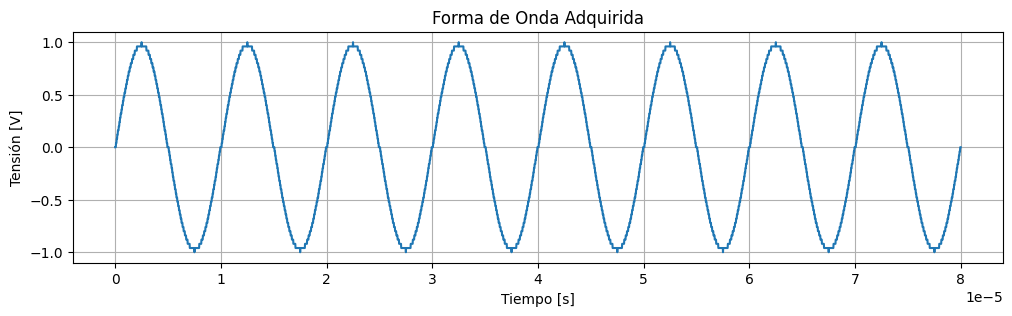

Se leyó datos originales desde: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\02 Analisis de datos\Onda_20260212_185625_procesado.h5


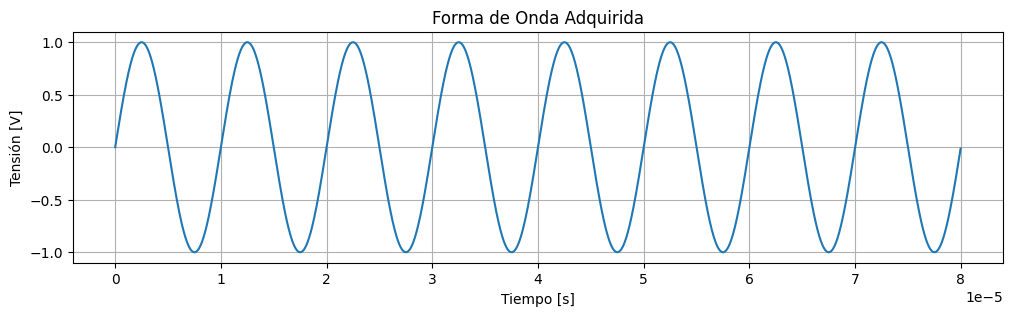

Se leyó datos originales desde: c:\Users\Demian\Documents\RepositorioGit\PI\PruebasManuales\Nro_Item\03 Resultados\Onda_20260212_185625_exportado.csv


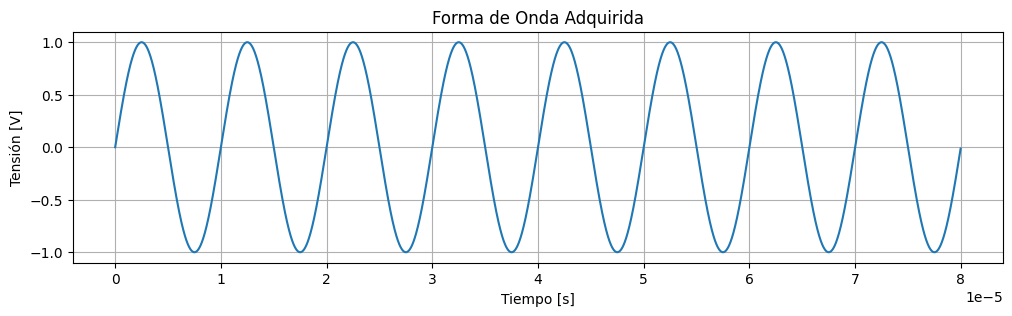

In [ ]:
from file_manager import *
from generar_senales import *
from gw_instek_gds1000a_u import *
from report_2 import *

if __name__ == '__main__':
    # 1. Al iniciar tu software, iniciar el gestor
    gestor = FileManager()

    bandera = True  # True: datos de prueba, False: datos desde osciloscopio

    if bandera:  # Generar datos de prueba
        dt = 20e-9
        binary_data, wave_form = generar_senales(dt)
    else:  # Obtener datos desde osciloscopio
        resource_manager = init_system()
        dso = init_instrument(resource_manager, 'ASRL6::INSTR')
        instrument = [resource_manager, dso]
        binary_data, wave_form, dt = get_block_data(instrument, 1)
    
    num_points = 4000
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)

    # 2. Guardar datos en .BIN:
    ruta_bin = gestor.get_new_name("Onda", ".bin")
    gestor.create_bin_int16(binary_data, ruta_bin)
    print(f"Se guardó datos originales en: {ruta_bin}")
    
    # 3. Guardar datos en .H5:
    nombre_base = ruta_bin.stem 
    ruta_h5 = gestor.analysis / f"{nombre_base}_procesado.h5"
    gestor.create_hdf5(time_axis, wave_form, ruta_h5)
    print(f"Se guardó datos procesados en: {ruta_h5}")

    # 4. Guardar datos en CSV:
    ruta_csv = gestor.results / f"{nombre_base}_exportado.csv"
    gestor.create_csv(time_axis, wave_form, ruta_csv)
    print(f"Se guardó datos exportados en: {ruta_csv}")

    # 5. Leer datos de .BIN, .H5 y .CSV y graficar:
    ruta_base = Path.cwd() / "DatosDePrueba"
    if bandera:
        wave1 = gestor.read_bin_without_header(ruta_bin)
        print(f"Se leyó datos originales desde: {ruta_bin}")
        #plot_waveform(wave1, dt)
        plot_waveform_2(wave1, time_axis)
    else:
        wave2, dt = gestor.read_bin_with_header(ruta_bin)
        print(f"Se leyó datos originales desde: {ruta_bin}")
        #plot_waveform(wave2, dt)
        plot_waveform_2(wave2, time_axis)

    wave3 = gestor.read_h5(ruta_h5)
    print(f"Se leyó datos originales desde: {ruta_h5}")
    #plot_waveform(wave3, dt)
    plot_waveform_2(wave3, time_axis)

    wave4 = gestor.read_csv(ruta_csv)
    print(f"Se leyó datos originales desde: {ruta_csv}")
    #plot_waveform(wave4, dt)
    plot_waveform_2(wave4, time_axis)

    if not bandera:
        close_system(instrument)
    '''
    # Evitar sobrescribir archivos existentes:
    Analizar el uso del siguiente código:
    
        if not os.path.exists("senales.csv"):
        # Guardar datos
        print("Se creó 'senales.csv'")
    else:
        print("El archivo ya existe, no se sobrescribió.")
    '''

# Prueba del Procesador de señales.
Utiliza los archivos:
- administrar_carpetas.py
- procesador_de_senales.py
- report.py.

1) Lee el archivo de datos de calibración, y extrae su información.
2) Imprime los metadatos de la señal y su gráfico.
3) Calcula y quita el offset de la señal. Imprime su gráfico.
4) Calcula el pico de la señal, determina su polaridad, y normaliza la señal para que el máximo sea unitario. Imprime su gráfico.
5) Calcula y encuentra Ue * 0.2 del frente y Ue * 0.4 de la cola. Imprime su gráfico.

# Probador de ondas ideales Plenas del TDG

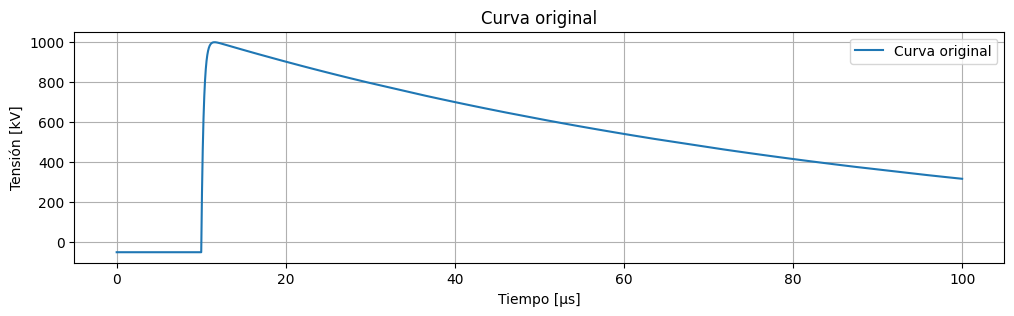

Offset removido: -50.00 kV


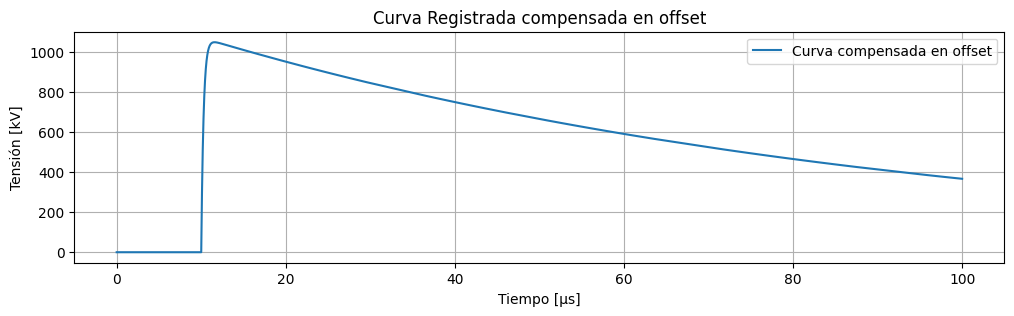

Pico detectado: 1049.59 kV
Polaridad: Positiva


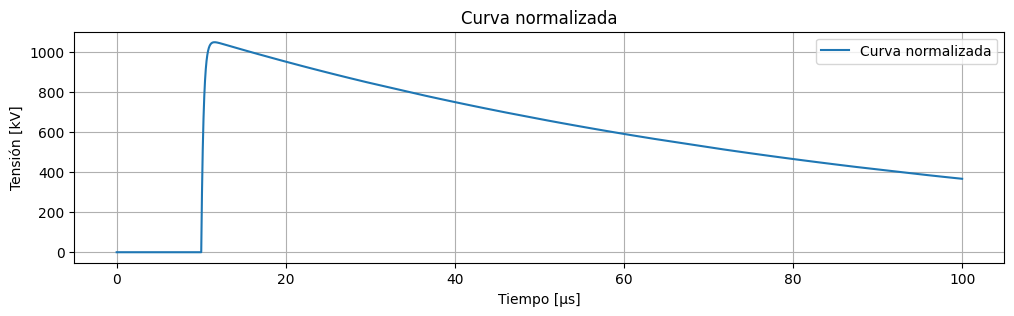

Muestras seleccionadas para ajuste = 7866.


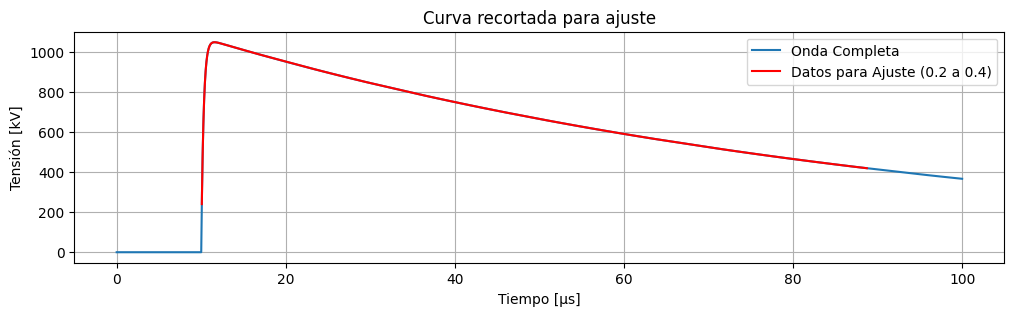

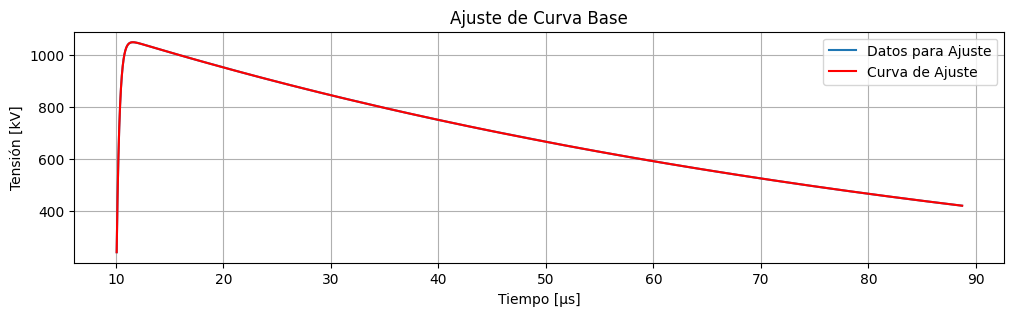

Máximo de tensión de la curva base (Ub): 1049.59 kV


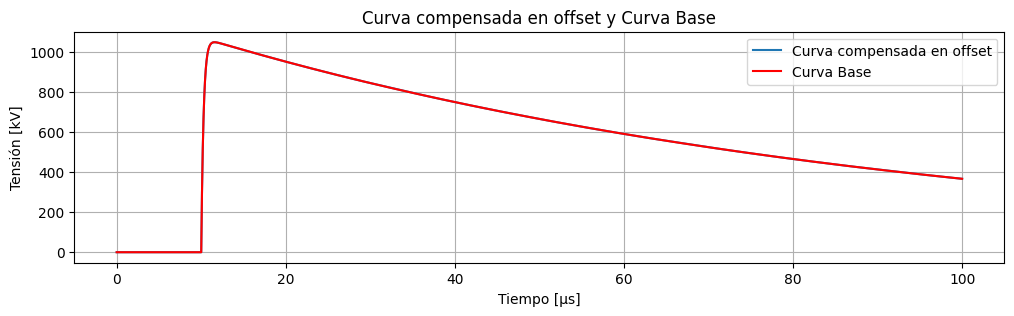

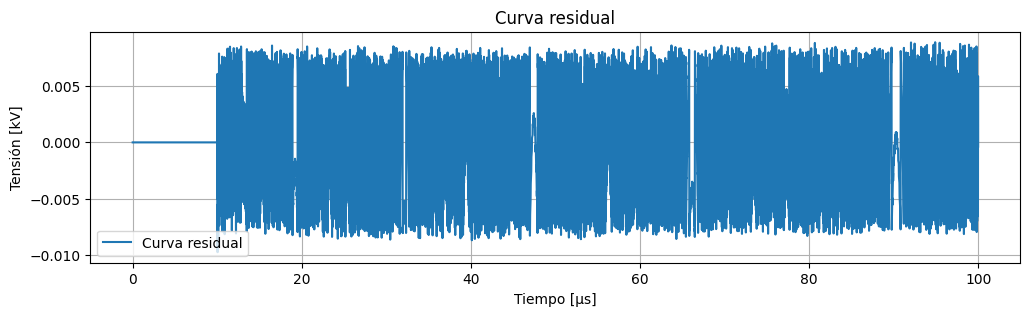

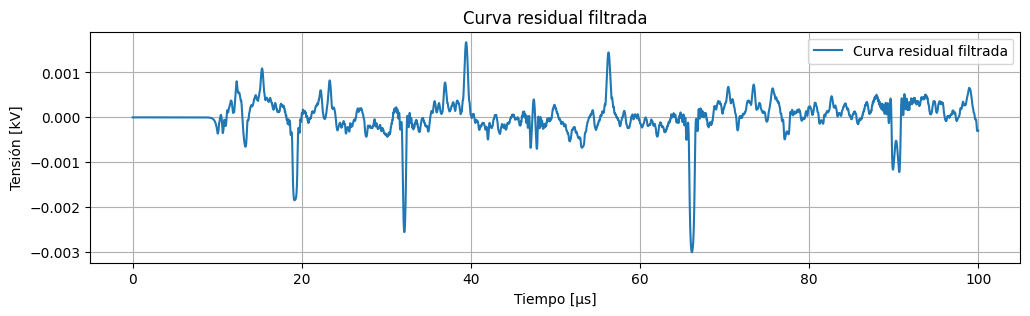

Valor máximo de la tensión de ensayo (Ut): 1049.59 kV


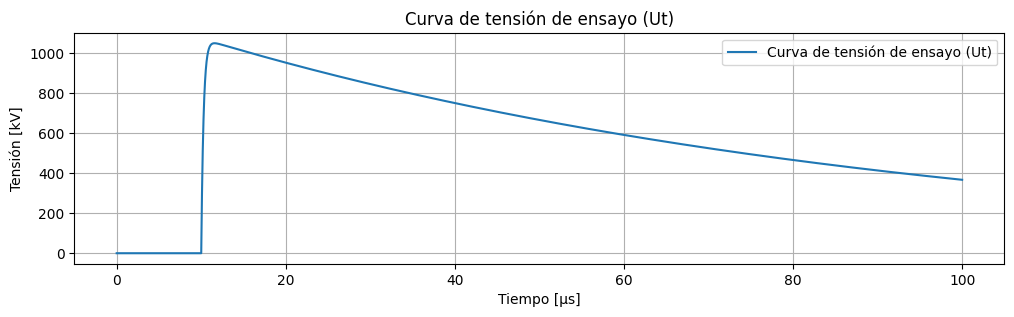

Parámetros característicos de la onda de impulso:
Ut = 1049.59 kV
T1 = 0.84 µs
T2 = 60.15 µs
O1 = 9.84 µs
Beta' = -0.00 %
Ue = 1049.59 kV
Ub = 1049.59 kV


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "LI-A1.txt"
    
    try:
        metadata, waveform = gestor.read_calibration_file(calibration_file)
        #print_information(metadata, waveform)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=1.0)

    bandera = False
    if bandera:
        analyzer.signal_processing()
        
        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer.results['Ue']/1e3:.3f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer.results['Ut']/1e3:.3f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Cola (T2):    {analyzer.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer.results['Beta_prime']:.2f} %")

        # Graficar resultado final
        plt.figure(figsize=(16, 10))
        plt.plot(analyzer.time_axis*1e6, analyzer.zeroed_curve, color='lightgreen', label='Original (U0)')
        plt.plot(analyzer.time_axis*1e6, analyzer.test_voltage_curve, color='red', linestyle='-', label='Test Voltage (Ut)')
        plt.plot(analyzer.time_axis*1e6, analyzer.base_curve * analyzer.factor, color='blue', linestyle='--', label='Base Curve (Um)')
        plt.xlabel("Tiempo [us]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        # Paso 0: Dibujar onda original.
        #plot_recorded_curve(analyzer.time_axis, waveform)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.raw_voltage/1e3, "Curva original", "Curva original")

        # Paso 1: Obtener la curva registrada compensada en offset.
        analyzer._remove_offset()
        print(f"Offset removido: {analyzer.offset_value/1000:.2f} kV")
        #plot_offset_compensated_curve(analyzer.time_axis, analyzer.zeroed_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve/1e3, "Curva compensada en offset", "Curva Registrada compensada en offset")

        # Paso 2: Detectar pico y normalizar.
        analyzer._polarity_normalization()
        analyzer._normalize_waveform()
        print(f"Pico detectado: {analyzer.peak_value/1000:.2f} kV")
        print(f"Polaridad: {analyzer.polarity}")
        # Graficar la señal normalizada
        #plot_normalized_curve(analyzer.time_axis, analyzer.norm_voltage)
        #plot_normalized_curve(analyzer.time_axis, analyzer.zeroed_curve_abs)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Curva normalizada", "Curva normalizada")

        # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
        analyzer._cutting_signal()
        print(f"Muestras seleccionadas para ajuste = {len(analyzer.fit_voltage)}.")
        #plot_cutting_signal(analyzer.time_axis, analyzer.zeroed_curve, analyzer.fit_time, analyzer.fit_voltage)
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Onda Completa", analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, "Datos para Ajuste (0.2 a 0.4)", "Curva recortada para ajuste")

        # Paso 4: Ajuste de la señal recortada con función de doble exponencial.
        analyzer._fit_base_curve()
        # Graficar la curva de ajuste encontrada junto con los datos recortados.
        #plot_fitting_signal(analyzer.fit_time, analyzer.fit_voltage, analyzer.fitted_curve)
        plot_2_waveform(analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, "Datos para Ajuste", analyzer.fit_time*1e6, analyzer.fitted_curve/1e3, "Curva de Ajuste", "Ajuste de Curva Base")

        # Paso 5: Obtener la curva base.
        analyzer._construct_base_curve()
        print(f"Máximo de tensión de la curva base (Ub): {analyzer.Ub/1000:.2f} kV")
        #plot_base_curve(analyzer.time_axis, analyzer.raw_voltage, analyzer.base_curve)
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Curva compensada en offset", analyzer.time_axis*1e6, analyzer.base_curve/1e3, "Curva Base", "Curva compensada en offset y Curva Base")

        # Paso 6: Calcular la curva residual.
        analyzer._calculate_residual_curve()
        #plot_residual_curve(analyzer.time_axis, analyzer.residual_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.residual_curve/1e3, "Curva residual", "Curva residual")

        # Paso 7: Filtrar la curva residual.
        analyzer._filter_to_residual()
        #plot_filtered_residual_curve(analyzer.time_axis, analyzer.filtered_residual)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.filtered_residual/1e3, "Curva residual filtrada", "Curva residual filtrada")

        # Paso 8: Calcular la curva de tensión de ensayo Ut(t) y su valor máximo Ut.
        analyzer._construct_test_voltage_curve()
        print(f"Valor máximo de la tensión de ensayo (Ut): {analyzer.Ut/1000:.2f} kV")
        #plot_test_voltage_curve(analyzer.time_axis, analyzer.test_voltage_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.test_voltage_curve/1e3, "Curva de tensión de ensayo (Ut)", "Curva de tensión de ensayo (Ut)")

        # Paso 9: Calcular los parámetros característicos de la onda de impulso.
        analyzer._calculate_parameters()

        print("Parámetros característicos de la onda de impulso:")
        print(f"Ut = {analyzer.results['Ut']/1e3:.2f} kV")
        print(f"T1 = {analyzer.results['T1']*1e6:.2f} µs")
        print(f"T2 = {analyzer.results['T2']*1e6:.2f} µs")
        print(f"O1 = {analyzer.results['O1']*1e6:.2f} µs")
        print(f"Beta' = {analyzer.results['Beta_prime']:.2f} %")
        print(f"Ue = {analyzer.results['Ue']/1e3:.2f} kV")
        print(f"Ub = {analyzer.results['Ub']/1e3:.2f} kV")

# Probador de ondas reales del LAT

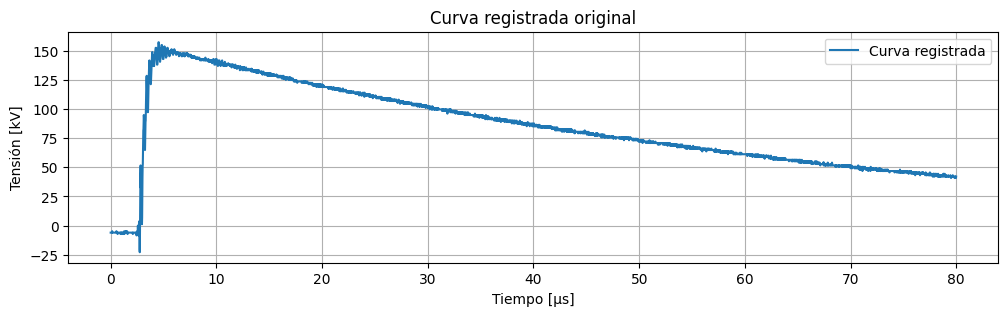

Offset removido: -6.03 kV


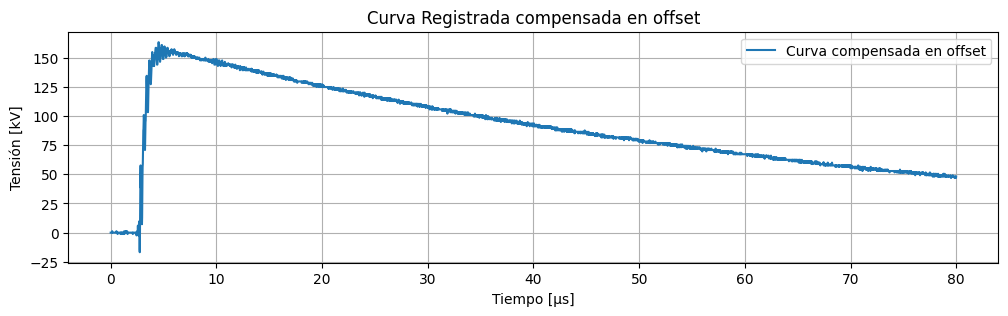

Pico detectado: 163.26 kV
Polaridad: Positiva


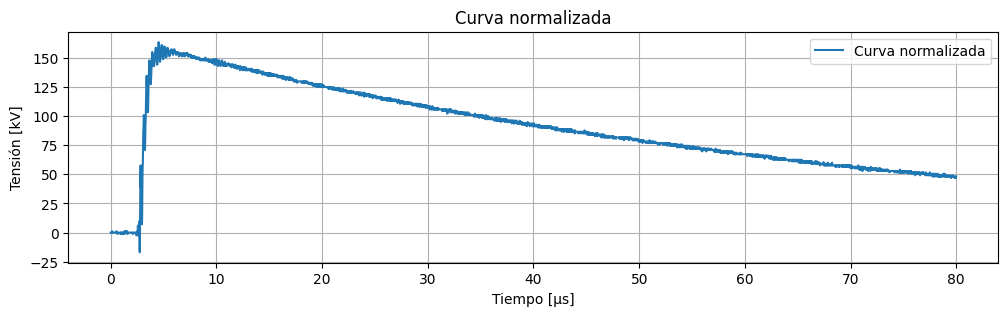

Muestras seleccionadas para ajuste = 3609.


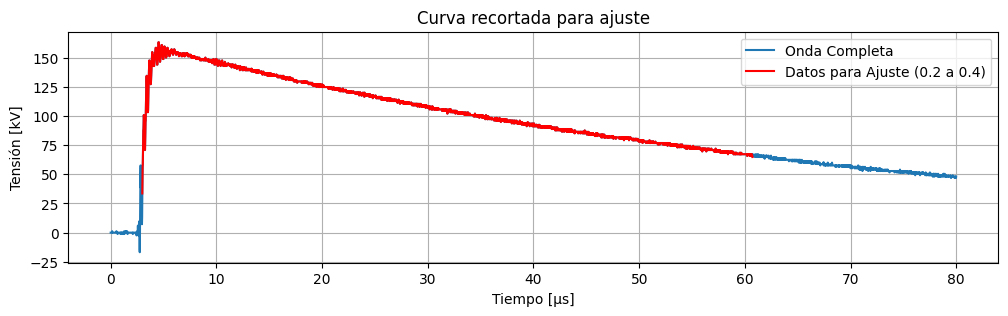

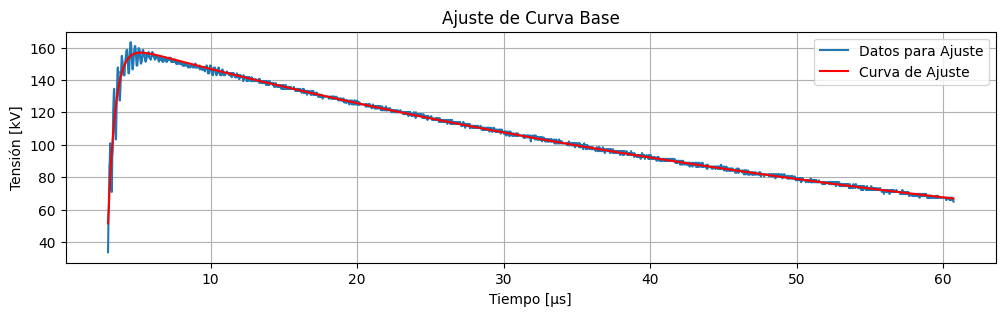

Máximo de tensión de la curva base (Ub): 156.84 kV


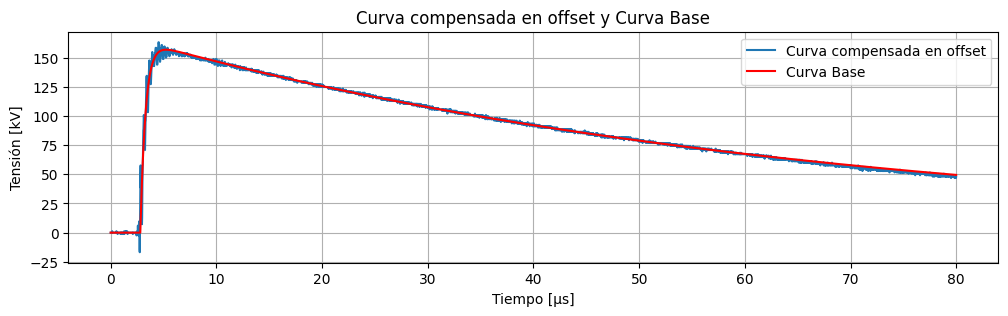

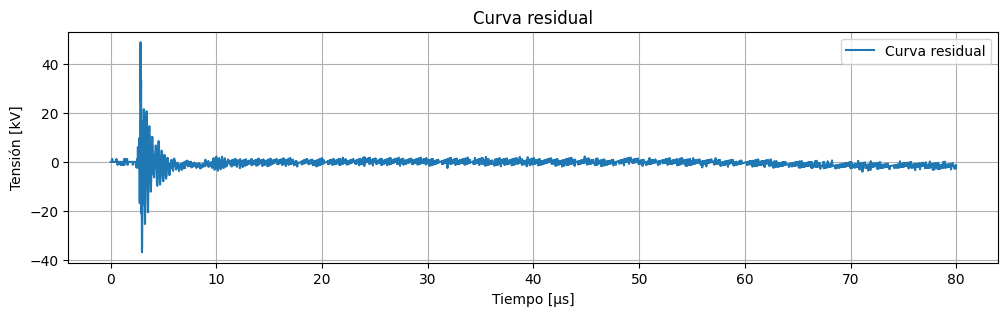

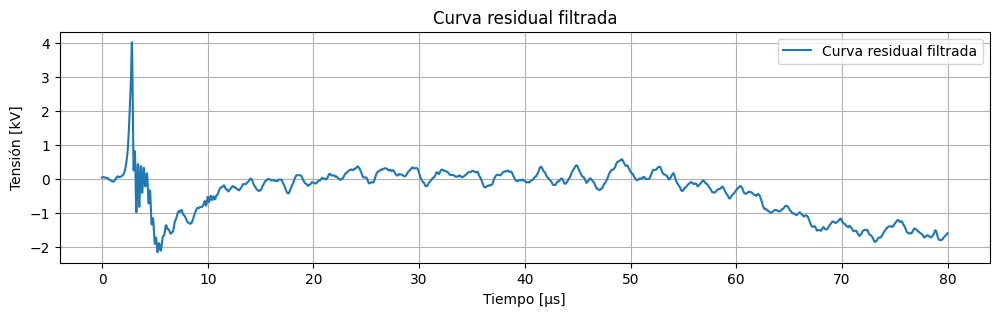

Valor máximo de la tensión de ensayo (Ut): 155.15 kV


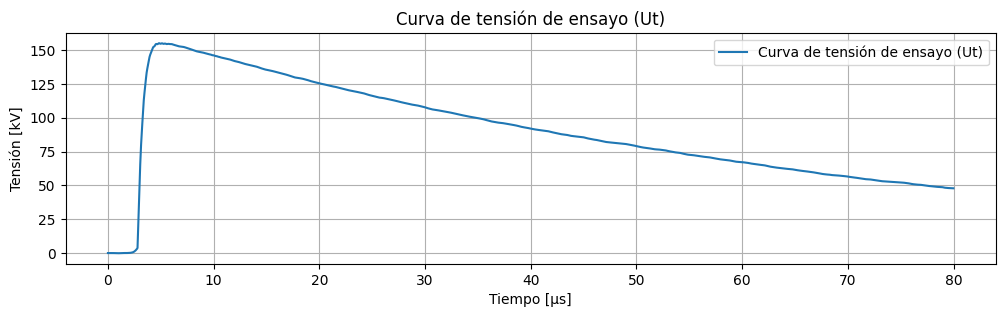

Parámetros característicos de la onda de impulso:
Ut = 155.15 kV
T1 = 1.40 µs
T2 = 48.51 µs
Beta' = 3.93 %


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file = Path.cwd().parent / "Calibracion" / "LAT" / "LAT_1.txt"
    
    try:
        metadata, waveform = gestor.read_calibration_file(calibration_file)
        #print_information(metadata, waveform)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")
    
    analyzer = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=0.2)
    analyzer.impulse_type = "full"

    bandera = False
    if bandera:
        analyzer.ref_lightning_impulse()

        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer.results['Ue']/1e3:.2f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer.results['Ut']/1e3:.2f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Cola (T2):    {analyzer.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer.results['Beta_prime']:.2f} %")

        # Graficar resultado final
        plt.figure(figsize=(16,10))
        plt.plot(analyzer.time_axis*1e6, analyzer.zeroed_curve, color='lightgreen', label='Original (U0)')
        plt.plot(analyzer.time_axis*1e6, analyzer.test_voltage_curve, color='red', linestyle='-', label='Test Voltage (Ut)')
        plt.plot(analyzer.time_axis*1e6, analyzer.base_curve * analyzer.factor, color='blue', linestyle='--', label='Base Curve (Um)')
        plt.xlim(0, 10)
        #plt.yticks(np.arange(-360, 1, 45)) # Paso de la grilla
        plt.xlabel("Tiempo [µs]")
        plt.ylabel("Voltaje [kV]")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        # Paso 0: Dibujar onda original.
        #plot_recorded_curve(analyzer.time_axis, waveform)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.raw_voltage/1e3, "Curva registrada", "Curva registrada original")
        
        # Paso 1: Obtener la curva registrada compensada en offset.
        analyzer._remove_offset()
        print(f"Offset removido: {analyzer.offset_value/1e3:.2f} kV")
        #plot_offset_compensated_curve(analyzer.time_axis, analyzer.zeroed_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve/1e3, "Curva compensada en offset", "Curva Registrada compensada en offset")

        # Paso 2: Detectar pico y normalizar.
        analyzer._polarity_normalization()
        analyzer._normalize_waveform()
        print(f"Pico detectado: {analyzer.Ue/1000:.2f} kV")
        print(f"Polaridad: {analyzer.polarity}")
        # Graficar la señal normalizada
        #plot_normalized_curve(analyzer.time_axis, analyzer.norm_voltage)
        #plot_normalized_curve(analyzer.time_axis, analyzer.zeroed_curve_abs)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Curva normalizada", "Curva normalizada")

        # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
        analyzer._cutting_signal()
        print(f"Muestras seleccionadas para ajuste = {len(analyzer.fit_voltage)}.")
        #plot_cutting_signal(analyzer.time_axis, analyzer.zeroed_curve_abs, analyzer.fit_time, analyzer.fit_voltage)
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Onda Completa", analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, "Datos para Ajuste (0.2 a 0.4)", "Curva recortada para ajuste")

        # Paso 4: Ajuste de la señal recortada con función de doble exponencial.
        analyzer._fit_base_curve()
        # Graficar la curva de ajuste encontrada junto con los datos recortados.
        #plot_fitting_signal(analyzer.fit_time, analyzer.fit_voltage, analyzer.fitted_curve)
        plot_2_waveform(analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, "Datos para Ajuste", analyzer.fit_time*1e6, analyzer.fitted_curve/1e3, "Curva de Ajuste", "Ajuste de Curva Base")

        # Paso 5: Obtener la curva base.
        analyzer._construct_base_curve()
        print(f"Máximo de tensión de la curva base (Ub): {analyzer.Ub/1000:.2f} kV")
        #plot_base_curve(analyzer.time_axis, analyzer.zeroed_curve_abs, analyzer.base_curve)
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Curva compensada en offset", analyzer.time_axis*1e6, analyzer.base_curve/1e3, "Curva Base", "Curva compensada en offset y Curva Base")
    
        # Paso 6: Calcular la curva residual.
        analyzer._calculate_residual_curve()
        #plot_residual_curve(analyzer.time_axis, analyzer.residual_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.residual_curve/1e3, "Curva residual", "Curva residual")

        # Paso 7: Filtrar la curva residual.
        analyzer._filter_to_residual()
        #plot_filtered_residual_curve(analyzer.time_axis, analyzer.filtered_residual)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.filtered_residual/1e3, "Curva residual filtrada", "Curva residual filtrada")

        # Paso 8: Calcular la curva de tensión de ensayo Ut(t) y su valor máximo Ut.
        analyzer._construct_test_voltage_curve()
        print(f"Valor máximo de la tensión de ensayo (Ut): {analyzer.Ut/1000:.2f} kV")
        #plot_test_voltage_curve(analyzer.time_axis, analyzer.test_voltage_curve)
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.test_voltage_curve/1e3, "Curva de tensión de ensayo (Ut)", "Curva de tensión de ensayo (Ut)")

        # Paso 9: Calcular los parámetros característicos de la onda de impulso.
        analyzer._calculate_parameters()
        
        print("Parámetros característicos de la onda de impulso:")
        print(f"Ut = {analyzer.results['Ut']/1e3:.2f} kV")
        print(f"T1 = {analyzer.results['T1']*1e6:.2f} µs")
        print(f"T2 = {analyzer.results['T2']*1e6:.2f} µs")
        print(f"Beta' = {analyzer.results['Beta_prime']:.2f} %")


# Probador de ondas ideales Cortadas del TDG


--- Parámetros de la onda ---
Tensión pico registrada (Ue): 0.14788 kV
Tensión pico de Ensayo (Ut): 0.14776 kV
Tiempo de Frente (T1):  1.305 µs
Tiempo de Corte (TC):    6.007 µs
Overshoot Relativo:     0.60 %


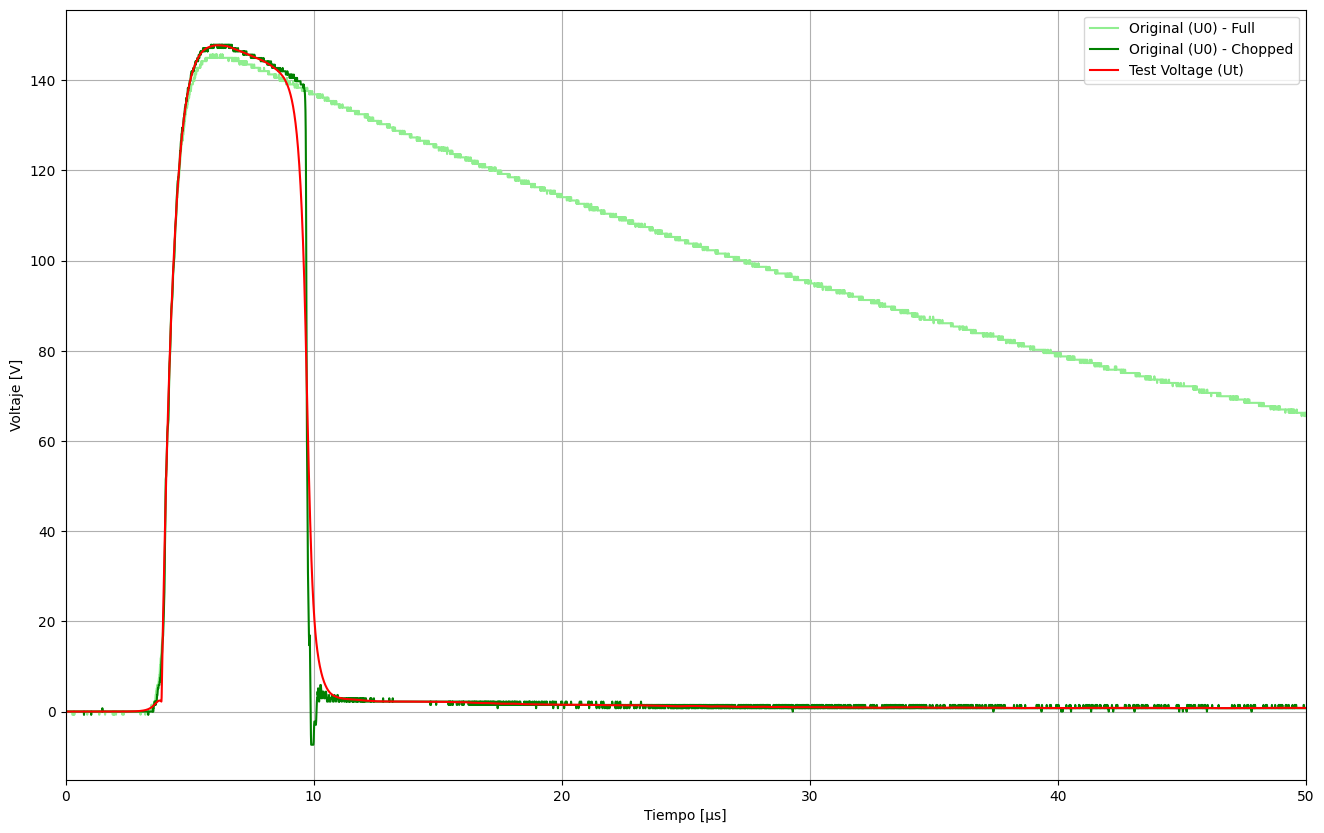

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file_f = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "LIC-M4f.txt"
    calibration_file_c = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "LIC-M4c.txt"

    try:
        metadata, waveform = gestor.read_calibration_file(calibration_file_f)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file_f}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer_f = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=1.0)

    try:
        metadata, waveform = gestor.read_calibration_file(calibration_file_c)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file_c}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer_c = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=1.0)

    bandera = True
    if bandera:
        analyzer_f.full_lightning_impulses()
        analyzer_c.chopped_lightning_impulses(analyzer_f)

        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer_c.results['Ue']/1e3:.5f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer_c.results['Ut']/1e3:.5f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer_c.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Corte (TC):    {analyzer_c.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer_c.results['Beta_prime']:.2f} %")

        # Graficar resultado final
        plt.figure(figsize=(16,10))
        plt.plot(analyzer_f.time_axis*1e6, analyzer_f.zeroed_curve, color='lightgreen', label='Original (U0) - Full')
        plt.plot(analyzer_c.time_axis*1e6, analyzer_c.zeroed_curve, color='green', label='Original (U0) - Chopped')
        plt.plot(analyzer_c.time_axis*1e6, analyzer_c.test_voltage_curve, color='red', linestyle='-', label='Test Voltage (Ut)')
        #plt.plot(analyzer_c.time_axis*1e6, analyzer_c.base_curve * analyzer_c.factor, color='blue', linestyle='--', label='Base Curve (Um)')
        #plt.plot(analyzer_c.time_axis*1e6, analyzer_c.chopped_norm_interp, color='orange', label='Interpolated (Ut)')
        plt.xlim(0, 50)
        #plt.yticks(np.arange(-360, 1, 45)) # Paso de la grilla
        plt.xlabel("Tiempo [µs]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.grid(True)
        plt.show()

In [ ]:
# Versión Entendible

class AtmosphericCorrectionClear:
    def __init__(self, u0, um, l_distance, pressure, temperature, rel_humidity, abs_humidity, tolerance=0.1):
        self.u0 = u0
        self.um = um
        self.l_distance = l_distance
        self.pressure = pressure
        self.temperature = temperature
        self.rel_humidity = rel_humidity
        self.abs_humidity = abs_humidity
        self.tolerance = tolerance

        self.warnings = []
        self.k1_flag = False

    def _check_early_exits(self):
        # Verifica si el equipo califica para correcciones atmosféricas.
        if self.um <= 72.5 or self.l_distance < 0.5:
            return True # No se aplican correcciones atmosféricas.
        return False # Se aplican correcciones atmosféricas.

    def _evaluate_environmental_warnings(self, h_delta):
        # Genera advertencias si las condiciones superan los límites normativos.
        if self.rel_humidity > 80.0:
            self.warnings.append("Humedad relativa > 80%. Posibles descargas irregulares sobre superficies aislantes.")

        if h_delta < 1.0 or h_delta > 20.0:
            self.warnings.append("El parámetro de humedad h/δ está fuera de los límites normativos (1 - 20 g/m³).")

    def _calculate_air_density(self):
        # Calcula la densidad relativa del aire (δ).
        return (self.pressure / 1013.0) * (293.0 / (273.0 + self.temperature))

    def _calculate_humidity_parameter(self, delta):
        # Calcula el parámetro k base para impulsos.
        h_delta = self.abs_humidity / delta
        self._evaluate_environmental_warnings(h_delta)
        return 1.0 + 0.010 * (h_delta - 11.0)

    def _get_exponents(self, g):
        # Función por tramos para obtener 'm' y 'w'.
        if g <= 0.2:
            return 0.0, 0.0
        elif 0.2 < g <= 1.0:
            val = g * (g - 0.2) / 0.8
            return val, val
        elif 1.0 < g <= 1.2:
            return 1.0, 1.0
        elif 1.2 < g < 2.0:
            w_val = (2.2 - g) * (2.0 - g) / 0.8
            return 1.0, w_val
        else: # g >= 2.0
            return 1.0, 0.0

    def calculate_correction(self):
        # Función principal que orquesta el procedimiento inverso.
        if self._check_early_exits():
            return self.u0, 1.0, self.warnings

        delta = self._calculate_air_density()
        k_param = self._calculate_humidity_parameter(delta)

        ut_prev = self.u0
        u50 = 1.1 * self.u0

        while True:
            # Calcular g.
            g = u50 / (500.0 * self.l_distance * delta * k_param)
            
            # Obtener exponentes.
            m, w = self._get_exponents(g)
            
            # Calcular factores.
            k1 = delta ** m
            k2 = k_param ** w
            
            # Actualizar bandera k1 (si sale de rango al menos una vez).
            if not self.k1_flag and (k1 < 0.8 or k1 > 1.05):
                self.warnings.append("Factor de densidad k1 fuera del rango confiable (0.8 - 1.05).")
                self.k1_flag = True

            # Calcular nuevo voltaje.
            kt = k1 * k2
            ut_current = kt * self.u0
            
            # Control de convergencia.
            if abs(ut_current - ut_prev) <= self.tolerance:
                break
                
            # Actualizar variables para la próxima iteración.
            ut_prev = ut_current
            u50 = 1.1 * ut_prev

        return ut_current, kt, self.warnings

# Versión Óptima (Potencia de librerías y exactitud)
from scipy.optimize import fixed_point

class AtmosphericCorrectionOptimal:
    def __init__(self, u0, um, l_distance, pressure, temperature, rel_humidity, abs_humidity, tolerance=0.1):
        self.u0 = u0
        self.um = um
        self.l_distance = l_distance
        self.pressure = pressure
        self.temperature = temperature
        self.rel_humidity = rel_humidity
        self.abs_humidity = abs_humidity
        self.tolerance = tolerance
        self.warnings = set() # Usa set para evitar advertencias duplicadas.

    def _evaluate_base_parameters(self):
        delta = (self.pressure / 1013.0) * (293.0 / (273.0 + self.temperature))
        h_delta = self.abs_humidity / delta
        k_param = 1.0 + 0.010 * (h_delta - 11.0)
        
        if self.rel_humidity > 80.0:
            self.warnings.add("Humedad relativa > 80%. Posibles descargas irregulares.")
        if not (1.0 <= h_delta <= 20.0):
            self.warnings.add("Parámetro de humedad h/δ fuera de los límites (1 - 20 g/m³).")
            
        return delta, k_param

    def _iteration_function(self, ut_guess, delta, k_param):
        # Función objetivo para el optimizador de punto fijo de SciPy.
        u50 = 1.1 * ut_guess
        g = u50 / (500.0 * self.l_distance * delta * k_param)
        
        if g <= 0.2:
            m, w = 0.0, 0.0
        elif 0.2 < g <= 1.0:
            m = w = g * (g - 0.2) / 0.8
        elif 1.0 < g <= 1.2:
            m, w = 1.0, 1.0
        elif 1.2 < g < 2.0:
            m, w = 1.0, (2.2 - g) * (2.0 - g) / 0.8
        else: # g >= 2.0
            m, w = 1.0, 0.0

        k1 = delta ** m
        if k1 < 0.8 or k1 > 1.05:
            self.warnings.add("Factor de densidad k1 fuera del rango confiable (0.8 - 1.05).")

        kt = k1 * (k_param ** w)
        return self.u0 * kt

    def calculate_correction(self):
        if self.um <= 72.5 or self.l_distance < 0.5:
            return self.u0, 1.0, list(self.warnings)

        delta, k_param = self._evaluate_base_parameters()

        # SciPy encuentra automáticamente el punto de convergencia
        try:
            ut_converged = fixed_point(
                func=self._iteration_function, 
                x0=self.u0, 
                args=(delta, k_param), 
                xtol=self.tolerance, 
                maxiter=500
            )
            # Calcular Kt final resultante.
            kt_final = ut_converged / self.u0
            
        except RuntimeError:
            self.warnings.add("El algoritmo de convergencia no pudo estabilizarse.")
            return self.u0, 1.0, list(self.warnings)

        return float(ut_converged), float(kt_final), list(self.warnings)

# Versión Rápida

class AtmosphericCorrectionFast:
    __slots__ = ['u0', 'um', 'l_distance', 'pressure', 'temperature', 'rel_humidity', 'abs_humidity', 'tolerance']

    def __init__(self, u0, um, l_distance, pressure, temperature, rel_humidity, abs_humidity, tolerance=0.1):
        self.u0 = u0
        self.um = um
        self.l_distance = l_distance
        self.pressure = pressure
        self.temperature = temperature
        self.rel_humidity = rel_humidity
        self.abs_humidity = abs_humidity
        self.tolerance = tolerance

    def calculate_correction(self):
        # Traspasar a variables locales para acelerar el acceso en memoria durante el bucle.
        u0_local = self.u0
        warnings = []
        
        if self.um <= 72.5 or self.l_distance < 0.5:
            return u0_local, 1.0, warnings

        # Cálculos pre-bucle
        delta = (self.pressure / 1013.0) * (293.0 / (273.0 + self.temperature))
        h_delta = self.abs_humidity / delta
        k_param = 1.0 + 0.010 * (h_delta - 11.0)
        
        if self.rel_humidity > 80.0:
            warnings.append("Humedad relativa > 80%.")
        if h_delta < 1.0 or h_delta > 20.0:
            warnings.append("Parámetro de humedad h/δ fuera de los límites.")

        # Variables locales del bucle.
        ut_prev = u0_local
        divisor = 500.0 * self.l_distance * delta * k_param
        k1_flag = False
        kt = 1.0

        # Bucle aplanado (Flattened loop) para máxima velocidad.
        while True:
            g = (1.1 * ut_prev) / divisor
            
            if g <= 0.2:
                m = w = 0.0
            elif g <= 1.0:
                m = w = g * (g - 0.2) / 0.8
            elif g <= 1.2:
                m = w = 1.0
            elif g < 2.0:
                m = 1.0
                w = (2.2 - g) * (2.0 - g) / 0.8
            else: # g >= 2.0
                m = 1.0
                w = 0.0

            k1 = delta ** m
            if not k1_flag and (k1 < 0.8 or k1 > 1.05):
                warnings.append("Factor k1 fuera de rango.")
                k1_flag = True

            kt = k1 * (k_param ** w)
            ut_current = kt * u0_local
            
            if abs(ut_current - ut_prev) <= self.tolerance:
                break
                
            ut_prev = ut_current

        return ut_current, kt, warnings

In [2]:
import time
# =============================================================================
# 4. VERSIÓN RÁPIDA modificada
# =============================================================================
class AtmosphericCorrection:
    __slots__ = ['u0', 'um', 'l_distance', 'pressure', 't_dry', 'rel_humidity', 'abs_humidity', 'tolerance']

    def __init__(self, u0, um, l_distance, pressure, t_dry, rel_humidity, abs_humidity, tolerance=0.1):
        self.u0 = float(u0)
        self.um = float(um)
        self.l_distance = float(l_distance)
        self.pressure = float(pressure)
        self.t_dry = float(t_dry)
        self.rel_humidity = float(rel_humidity)
        self.abs_humidity = float(abs_humidity)
        self.tolerance = float(tolerance)

    def calculate_correction(self):
        u0_local = self.u0
        k1_flag = False
        warnings = []

         # Verifica si el equipo califica para correcciones atmosféricas.
        if self.um <= 72.5:
            warnings.append("No se aplicará el factor de corrección. Para aislamientos de equipos con Um ≤ 72,5 kV actualmente no se pueden especificar correcciones por densidad del aire ni por humedad (IEC 60060-1:2025, 4.3.4.1 y 4.3.4.2).")
        if self.l_distance < 0.5:
            warnings.append("No se aplicará el factor de corrección. Para distancias de descarga L < 0,5 m actualmente no se pueden especificar correcciones por densidad del aire ni por humedad (IEC 60060-1:2025, 4.3.4.1 y 4.3.4.2).")
        if self.um <= 72.5 or self.l_distance < 0.5:
            return u0_local, 1.0, warnings

        # Densidad relativa del aire (δ).
        delta = (self.pressure / 1013.0) * (293.0 / (273.0 + self.t_dry))
        # Calcula el parámetro k base para impulsos.
        h_delta = self.abs_humidity / delta

        if self.rel_humidity > 80.0:
            warnings.append("Advertencia: Humedad relativa > 80%. Las descargas pueden ser irregulares sobre superficies aislantes (IEC 60060-1:2025, 4.3.2).")
        if h_delta < 1.0 or h_delta > 20.0:
            warnings.append("Advertencia: El parámetro h/δ está fuera de los límites de validez para impulsos (1 - 20 g/m³) (IEC 60060-1:2025, 4.3.4.2).")

        k_param = 1.0 + 0.010 * (h_delta - 11.0)

        ut_prev = u0_local
        divisor = 500.0 * self.l_distance * delta * k_param
        kt = 1.0
        max_iter = 10_000
        iterations = 0

        while iterations < max_iter:
            iterations += 1
            # Parámetro g.
            g = (1.1 * ut_prev) / divisor
            # Obtener los exponentes 'm' y 'w'.
            if g <= 0.2:
                m = w = 0.0
            elif g <= 1.0: 
                m = w = g * (g - 0.2) / 0.8
            elif g <= 1.2:
                m = w = 1.0
            elif g < 2.0:
                m = 1.0
                w = (2.2 - g) * (2.0 - g) / 0.8
            else: # g >= 2.0
                m = 1.0
                w = 0.0

            # Factor de corrección por densidad del aire.
            k1 = delta ** m
            # Factor de corrección por humedad.
            k2 = k_param ** w

            # Actualizar bandera de k1 si sale de rango al menos una vez.
            if not k1_flag and (k1 < 0.8 or k1 > 1.05):
                warnings.append("Factor de densidad k1 fuera del rango confiable (0.8 - 1.05).")
                k1_flag = True

            # Factor de corrección total.
            kt = k1 * k2
            # Tensión corregida.
            ut_current = kt * u0_local

            # Control de convergencia.
            if abs(ut_current - ut_prev) <= self.tolerance:
                break

            ut_prev = ut_current

        if iterations >= max_iter:
            warnings.append("Advertencia de Software: Se alcanzó el límite máximo de iteraciones (10000) sin converger el valor de la tensión corregida. Revise los datos.")

        return ut_current, kt, warnings

# =============================================================================
# BENCHMARKING (Prueba de rendimiento)
# =============================================================================
def run_benchmark():
    # Datos basados en el Ejemplo del Anexo E de la norma IEC 60060-1
    # U0 especificada = 395 kV RMS -> Pico = 558.6 kV
    params = {
        "u0": 558.6,
        "um": 300.0,
        "l_distance": 2.57,
        "pressure": 769.6,
        "t_dry": 15.0,
        "rel_humidity": 35.0,
        "abs_humidity": 4.4765,
        "tolerance": 0.1
    }

    iteraciones = 100_000

    inst_fast = AtmosphericCorrection(**params)
    start = time.perf_counter()
    for _ in range(iteraciones):
        ut_f, kt_f, _ = inst_fast.calculate_correction()
    time_fast = time.perf_counter() - start

    # Resultados
    print("\n[Resultados Matemáticos (Tensión Corregida | Kt)]")
    print(f"Rápida modificada : {ut_f:.2f} kV | Kt = {kt_f:.4f}")

    print("\n[Tiempos de Ejecución Totales]")
    print(f"Rápida modificada : {time_fast:.4f} segundos")

if __name__ == "__main__":
    run_benchmark()


[Resultados Matemáticos (Tensión Corregida | Kt)]
Rápida modificada : 509.72 kV | Kt = 0.9125

[Tiempos de Ejecución Totales]
Rápida modificada : 0.2741 segundos


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from fpdf import FPDF
from datetime import datetime

# =========================================================================================
# BASE DE DATOS NORMATIVA - IEC 61083-2 (Anexos A y B)
# Contiene tolerancias (Anexo A) e Incertidumbres Expandidas Ux (Anexo B)
# Estructura: "Waveform_ID": {"Parametro": {"limit": %, "ux": %}}
# =========================================================================================
IEC_61083_2_DATA = {
    # GRUPO LI (Lightning Impulse).
    "LI-A1":  {"Ut": {"limit": 0.10, "ux": 0.002}, "T1": {"limit": 2.0, "ux": 0.011}, "T2": {"limit": 1.0, "ux": 0.003}, "Beta_prime": {"limit": 1.0, "ux": 0.001}},
    "LI-A2":  {"Ut": {"limit": 0.10, "ux": 0.008}, "T1": {"limit": 2.0, "ux": 0.12},  "T2": {"limit": 1.0, "ux": 0.011}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-A3":  {"Ut": {"limit": 0.10, "ux": 0.02},  "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.04},  "Beta_prime": {"limit": 1.0, "ux": 0.007}},
    "LI-A4":  {"Ut": {"limit": 0.10, "ux": 0.005}, "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.012}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-A5":  {"Ut": {"limit": 0.10, "ux": 0.006}, "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.05}},
    "LI-A6":  {"Ut": {"limit": 0.10, "ux": 0.005}, "T1": {"limit": 2.0, "ux": 0.4},   "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-A7":  {"Ut": {"limit": 0.10, "ux": 0.011}, "T1": {"limit": 2.0, "ux": 0.5},   "T2": {"limit": 1.0, "ux": 0.04},  "Beta_prime": {"limit": 1.0, "ux": 0.07}},
    "LI-A8":  {"Ut": {"limit": 0.10, "ux": 0.009}, "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.03}},
    "LI-A9":  {"Ut": {"limit": 0.10, "ux": 0.007}, "T1": {"limit": 2.0, "ux": 0.12},  "T2": {"limit": 1.0, "ux": 0.015}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-A10": {"Ut": {"limit": 0.10, "ux": 0.009}, "T1": {"limit": 2.0, "ux": 0.4},   "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.05}},
    "LI-A11": {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.009}, "Beta_prime": {"limit": 1.0, "ux": 0.010}},
    "LI-A12": {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.2},   "T2": {"limit": 1.0, "ux": 0.009}, "Beta_prime": {"limit": 1.0, "ux": 0.007}},
    "LI-M1":  {"Ut": {"limit": 0.10, "ux": 0.007}, "T1": {"limit": 2.0, "ux": 0.4},   "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.003}},
    "LI-M2":  {"Ut": {"limit": 0.10, "ux": 0.015}, "T1": {"limit": 2.0, "ux": 0.09},  "T2": {"limit": 1.0, "ux": 0.006}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-M3":  {"Ut": {"limit": 0.10, "ux": 0.02},  "T1": {"limit": 2.0, "ux": 0.13},  "T2": {"limit": 1.0, "ux": 0.015}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-M4":  {"Ut": {"limit": 0.10, "ux": 0.03},  "T1": {"limit": 2.0, "ux": 0.4},   "T2": {"limit": 1.0, "ux": 0.06},  "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-M5":  {"Ut": {"limit": 0.10, "ux": 0.010}, "T1": {"limit": 2.0, "ux": 0.4},   "T2": {"limit": 1.0, "ux": 0.05},  "Beta_prime": {"limit": 1.0, "ux": 0.08}},
    "LI-M6":  {"Ut": {"limit": 0.10, "ux": 0.005}, "T1": {"limit": 2.0, "ux": 0.02},  "T2": {"limit": 1.0, "ux": 0.007}, "Beta_prime": {"limit": 1.0, "ux": 0.014}},
    "LI-M7":  {"Ut": {"limit": 0.10, "ux": 0.02},  "T1": {"limit": 2.0, "ux": 0.3},   "T2": {"limit": 1.0, "ux": 0.05},  "Beta_prime": {"limit": 1.0, "ux": 0.04}},
    "LI-M8":  {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.08},  "T2": {"limit": 1.0, "ux": 0.004}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-M9":  {"Ut": {"limit": 0.10, "ux": 0.006}, "T1": {"limit": 2.0, "ux": 0.08},  "T2": {"limit": 1.0, "ux": 0.02},  "Beta_prime": {"limit": 1.0, "ux": 0.007}},
    "LI-M10": {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.09},  "T2": {"limit": 1.0, "ux": 0.003}, "Beta_prime": {"limit": 1.0, "ux": 0.011}},
    "LI-M11": {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.07},  "T2": {"limit": 1.0, "ux": 0.005}, "Beta_prime": {"limit": 1.0, "ux": 0.002}},
    "LI-M12": {"Ut": {"limit": 0.10, "ux": 0.008}, "T1": {"limit": 2.0, "ux": 0.2},   "T2": {"limit": 1.0, "ux": 0.011}, "Beta_prime": {"limit": 1.0, "ux": 0.05}},
    "LI-M13": {"Ut": {"limit": 0.10, "ux": 0.004}, "T1": {"limit": 2.0, "ux": 0.2},   "T2": {"limit": 1.0, "ux": 0.013}, "Beta_prime": {"limit": 1.0, "ux": 0.014}},
    "LI-M14": {"Ut": {"limit": 0.10, "ux": 0.012}, "T1": {"limit": 2.0, "ux": 0.2},   "T2": {"limit": 1.0, "ux": 0.04},  "Beta_prime": {"limit": 1.0, "ux": 0.04}},
    "LI-M15": {"Ut": {"limit": 0.10, "ux": 0.005}, "T1": {"limit": 2.0, "ux": 0.11},  "T2": {"limit": 1.0, "ux": 0.007}, "Beta_prime": {"limit": 1.0, "ux": 0.02}},
    "LI-M16": {"Ut": {"limit": 0.10, "ux": 0.005}, "T1": {"limit": 2.0, "ux": 0.10},  "T2": {"limit": 1.0, "ux": 0.010}, "Beta_prime": {"limit": 1.0, "ux": 0.006}},
    "LI-M17": {"Ut": {"limit": 0.10, "ux": 0.003}, "T1": {"limit": 2.0, "ux": 0.04},  "T2": {"limit": 1.0, "ux": 0.002}, "Beta_prime": {"limit": 1.0, "ux": 0.003}},

    # GRUPO LIC (Chopped Lightning Impulse).
    "LIC-A1": {"Ut": {"limit": 1.0, "ux": 0.005}, "T2": {"limit": 2.0, "ux": 0.005}},
    "LIC-M1": {"Ut": {"limit": 1.0, "ux": 0.07},  "T2": {"limit": 2.0, "ux": 0.12}},
    "LIC-M2": {"Ut": {"limit": 1.0, "ux": 0.02},  "T2": {"limit": 2.0, "ux": 0.4}},
    "LIC-M3": {"Ut": {"limit": 1.0, "ux": 0.02},  "T2": {"limit": 2.0, "ux": 0.2}},
    "LIC-M4": {"Ut": {"limit": 1.0, "ux": 0.03},  "T1": {"limit": 2.0, "ux": 0.6}, "T2": {"limit": 2.0, "ux": 0.3}, "Beta_prime": {"limit": 1.0, "ux": 0.05}},
    "LIC-M5": {"Ut": {"limit": 1.0, "ux": 0.05},  "T1": {"limit": 2.0, "ux": 0.9}, "T2": {"limit": 2.0, "ux": 0.2}, "Beta_prime": {"limit": 1.0, "ux": 0.04}},
}

class SoftwareUncertaintyReport:
    """
    Evaluar y documentar la incertidumbre del software según la norma IEC 61083-2,
    utilizando el Método Alternativo del Anexo B.
    """
    def __init__(self, software_name="Analizador de Impulsos", software_version="1.0", tdg_version="IEC 61083-2 TDG Version 2.1.0"):
        self.software_name = software_name
        self.software_version = software_version
        self.tdg_version = tdg_version

        # Almacenamiento de datos de la evaluación.
        self.evaluated_groups = ["LI", "LIC"]
        self.tested_parameters = {"LI": set(), "LIC": set()}
        self.failed_waveforms = []
        self.uncertainty_results = {} # {"LI": {"Ut": 0.12, ...}, "LIC": {...}}

    def add_evaluation_group(self, group_name: str, calculated_data: dict, reference_test_cases: list):
        """
        Evaluación completa de los grupos de ondas.
        - calculated_data: Diccionario con los resultados de tu impulse_analyzer.py
        - reference_test_cases: Lista de objetos ImpulseCase provenientes de test_cases_data.py
        """
        # Evaluar Límites de aceptación. Comparar los valores calculados con las tolerancias del Anexo A.
        self._evaluate_acceptance_limits(group_name, calculated_data, reference_test_cases)

        # Evaluar Incertidumbre del Software. Calcular la incertidumbre expandida U_B7 para cada parámetro según el Anexo B.
        self.calculate_uncertainty_optimal(group_name, calculated_data, reference_test_cases)

    def _evaluate_acceptance_limits(self, group_name: str, calculated_data: dict, ref_cases: list):
        """
        Compara los valores calculados con la tolerancia del Anexo A.
        Registra los fallos.
        """
        for case in ref_cases:
            waveform_id = case.file_id
            if waveform_id not in calculated_data:
                continue

            calc_results = calculated_data[waveform_id]
            norm_data = IEC_61083_2_DATA.get(waveform_id, {})

            # Diccionario para mapear las variables del objeto case.
            ref_mapping = {
                "Ut": (case.expected_peak, norm_data.get("Ut", {}).get("limit", float('inf'))),
                "T1": (case.expected_T1, norm_data.get("T1", {}).get("limit", float('inf'))),
                "T2": (case.expected_T2, norm_data.get("T2", {}).get("limit", float('inf'))),
                "Beta_prime": (case.expected_beta, norm_data.get("Beta_prime", {}).get("limit", float('inf')))
            }

            for param, (ref_val, limit_val) in ref_mapping.items():
                calc_val = calc_results.get(param)

                if calc_val is None or math.isnan(ref_val):
                    continue # Ignorar si el analizador no lo calculó o no aplica a esta onda.

                self.tested_parameters[group_name].add(param)

                # Error relativo (Ut, T1, T2) o absoluto (Beta).
                if param == "Beta_prime":
                    error = abs(calc_val - ref_val)
                else:
                    error = abs((calc_val - ref_val) / ref_val) * 100.0

                # Evaluación
                if error > limit_val:
                    self.failed_waveforms.append({
                        "group": group_name,
                        "waveform": waveform_id,
                        "parameter": param,
                        "error": error,
                        "limit": limit_val
                    })

    # =========================================================================================
    # VERSIÓN 1: ÓPTIMA (Mayor exactitud y procesamiento masivo con Numpy)
    # =========================================================================================
    def calculate_uncertainty_optimal(self, group_name: str, calculated_data: dict, ref_cases: list):
        self.uncertainty_results.setdefault(group_name, {})
        parameters = ["Ut", "T1", "T2", "Beta_prime"]

        for param in parameters:
            calc_arr = []
            ref_arr = []
            ux_arr = []

            for case in ref_cases:
                waveform_id = case.file_id
                if waveform_id not in calculated_data or calculated_data[waveform_id].get(param) is None:
                    continue

                ref_val = getattr(case, f"expected_{'peak' if param == 'Ut' else ('beta' if param == 'Beta_prime' else param)}")
                if math.isnan(ref_val):
                    continue

                calc_arr.append(calculated_data[waveform_id][param])
                ref_arr.append(ref_val)
                ux_arr.append(IEC_61083_2_DATA[waveform_id][param]["ux"])

            if not calc_arr:
                continue

            c = np.array(calc_arr, dtype=np.float64)
            r = np.array(ref_arr, dtype=np.float64)
            ux = np.array(ux_arr, dtype=np.float64)

            # Determianción del tipo de error, relativo o absoluto.
            if param == "Beta_prime":
                errors = np.abs(c - r)
            else:
                errors = np.abs((c - r) / r) * 100.0
            
            # u_B71: Error de desviación del software.
            u_b71 = np.max(errors) / np.sqrt(3.0)

            # u_B72: Incertidumbre intrínseca de la referencia.
            u_b72 = np.max(ux) / 2.0

            # Incertidumbre estándar combinada.
            u_b7 = np.sqrt(u_b71**2 + u_b72**2)
            self.uncertainty_results[group_name][param] = float(u_b7)

    # =========================================================================================
    # VERSIÓN 2: RÁPIDA (Prioriza velocidad de ejecución sin dependencias de terceros)
    # =========================================================================================
    def calculate_uncertainty_fast(self, group_name: str, calculated_data: dict, ref_cases: list):
        self.uncertainty_results.setdefault(group_name, {})
        parameters = ["Ut", "T1", "T2", "Beta_prime"]

        for param in parameters:
            valid_cases = [c for c in ref_cases if c.file_id in calculated_data 
                           and calculated_data[c.file_id].get(param) is not None 
                           and not math.isnan(getattr(c, f"expected_{'peak' if param == 'Ut' else ('beta' if param == 'Beta_prime' else param)}"))]
            
            if not valid_cases:
                continue

            calc_vals = [calculated_data[c.file_id][param] for c in valid_cases]
            ref_vals = [getattr(c, f"expected_{'peak' if param == 'Ut' else ('beta' if param == 'Beta_prime' else param)}") for c in valid_cases]
            ux_vals = [IEC_61083_2_DATA[c.file_id][param]["ux"] for c in valid_cases]

            if param == "Beta_prime":
                errors = [abs(c - r) for c, r in zip(calc_vals, ref_vals)]
            else:
                errors = [abs((c - r) / r) * 100.0 for c, r in zip(calc_vals, ref_vals)]

            u_b71 = max(errors) / math.sqrt(3.0)
            u_b72 = max(ux_vals) / 2.0
            
            self.uncertainty_results[group_name][param] = math.hypot(u_b71, u_b72)

    # =========================================================================================
    # VERSIÓN 3: ENTENDIBLE (Fácil lectura, proceso iterativo explícito)
    # =========================================================================================
    def calculate_uncertainty_understandable(self, group_name: str, calculated_data: dict, ref_cases: list):
        if group_name not in self.uncertainty_results:
            self.uncertainty_results[group_name] = {}
            
        parameters = ["Ut", "T1", "T2", "Beta_prime"]

        for param in parameters:
            max_error = 0.0
            max_ux = 0.0
            has_data = False

            for case in ref_cases:
                waveform_id = case.file_id
                
                if waveform_id not in calculated_data:
                    continue
                
                calc_val = calculated_data[waveform_id].get(param)
                if calc_val is None:
                    continue

                if param == "Ut":
                    ref_val = case.expected_peak
                elif param == "Beta_prime":
                    ref_val = case.expected_beta
                else:
                    ref_val = getattr(case, f"expected_{param}")

                if math.isnan(ref_val):
                    continue
                
                has_data = True
                ux_val = IEC_61083_2_DATA[waveform_id][param]["ux"]

                # Paso 1: Obtener el error máximo absoluto o relativo
                if param == "Beta_prime":
                    current_error = abs(calc_val - ref_val)
                else:
                    current_error = abs((calc_val - ref_val) / ref_val) * 100.0
                
                if current_error > max_error:
                    max_error = current_error

                # Paso 2: Encontrar la máxima incertidumbre de la referencia
                if ux_val > max_ux:
                    max_ux = ux_val

            if has_data:
                # Paso 3 y 4: Calcular componentes finales y unirlas
                u_b71 = max_error / math.sqrt(3.0)
                u_b72 = max_ux / 2.0
                u_b7 = math.sqrt((u_b71 ** 2) + (u_b72 ** 2))
                
                self.uncertainty_results[group_name][param] = u_b7

    # =========================================================================================
    # GENERACIÓN DEL REPORTE FINAL EN PDF
    # =========================================================================================
    def generate_pdf_report(self, filepath: str):
        """Genera un archivo PDF con formato normativo."""
        pdf = FPDF()
        pdf.add_page()

        # Estilos generales
        pdf.set_fill_color(240, 240, 240)

        # Título
        pdf.set_font("Arial", 'B', 16)
        pdf.cell(0, 15, "Record of Performance - IEC 61083-2", ln=True, align='C', fill=True)
        pdf.ln(5)

        # Metadatos del Software
        pdf.set_font("Arial", 'B', 12)
        pdf.cell(0, 10, "1. System Information", ln=True)
        pdf.set_font("Arial", '', 11)
        pdf.cell(0, 8, f"Date of Generation: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", ln=True)
        pdf.cell(0, 8, f"Software Name: {self.software_name}", ln=True)
        pdf.cell(0, 8, f"Software Version: {self.software_version}", ln=True)
        pdf.cell(0, 8, f"Reference Data Source: {self.tdg_version}", ln=True)
        pdf.ln(5)

        # Algoritmos Validados
        pdf.set_font("Arial", 'B', 12)
        pdf.cell(0, 10, "2. Validated Algorithms and Parameters", ln=True)
        pdf.set_font("Arial", '', 11)
        if not self.evaluated_groups:
            pdf.cell(0, 8, "No algorithms evaluated.", ln=True)
        else:
            for group in self.evaluated_groups:
                params_str = ", ".join(sorted(self.tested_parameters[group]))
                pdf.cell(0, 8, f"- Algorithm: {group} (Tested parameters: {params_str})", ln=True)
        pdf.ln(5)

        # Resultados de la Fase 3 (Límites)
        pdf.set_font("Arial", 'B', 12)
        pdf.cell(0, 10, "3. Acceptance Limits Evaluation (Annex A)", ln=True)
        pdf.set_font("Arial", '', 11)
        if self.failed_waveforms:
            pdf.set_text_color(200, 0, 0) # Rojo
            pdf.cell(0, 8, "WARNING: The software FAILED the acceptance limits for the following cases:", ln=True)
            for fail in self.failed_waveforms:
                pdf.cell(0, 8, f"  > [{fail['group']}] Waveform {fail['waveform']} ({fail['parameter']}): "
                               f"Error {fail['error']:.3f} % > Limit {fail['limit']} %", ln=True)
            pdf.set_text_color(0, 0, 0)
        else:
            pdf.cell(0, 8, "PASSED: All calculated parameters are strictly within IEC 61083-2 acceptance limits.", ln=True)
        pdf.ln(5)

        # Resultados de la Fase 4 (Incertidumbre)
        pdf.set_font("Arial", 'B', 12)
        pdf.cell(0, 10, "4. Software Standard Uncertainty (u_B7) - Alternative Method (Annex B)", ln=True)
        pdf.set_font("Arial", '', 11)
        
        for group, params in self.uncertainty_results.items():
            pdf.set_font("Arial", 'B', 11)
            pdf.cell(0, 8, f"Group: {group}", ln=True)
            pdf.set_font("Arial", '', 11)
            for param, u_b7 in params.items():
                pdf.cell(0, 8, f"  - {param}: {u_b7:.4f} %", ln=True)
            pdf.ln(2)
                
        pdf.output(filepath)
        print(f"Reporte de desempeño PDF generado con éxito en: {filepath}")